# PHASE 1 : Chargement, exploration, prétraitement


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Chargement


In [15]:
df = pd.read_csv("C:\\Users\\khaye\\Downloads\\heart_disease_dataset\\heart.csv")

print("Shape :", df.shape)
print("\nAperçu :")
print(df.head())

print("\nTypes :")
print(df.dtypes)

print("\nValeurs manquantes :")
print(df.isnull().sum())

print("\nStatistiques descriptives :")
print(df.describe())
print(f"Doublons : {df.duplicated().sum()}")


Shape : (1025, 14)

Aperçu :
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Types :
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Valeurs manquantes :
age         0
sex         0

## Distribution de la cible

C:\Users\khaye\AppData\Local\Temp\ipykernel_27516\2795716048.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


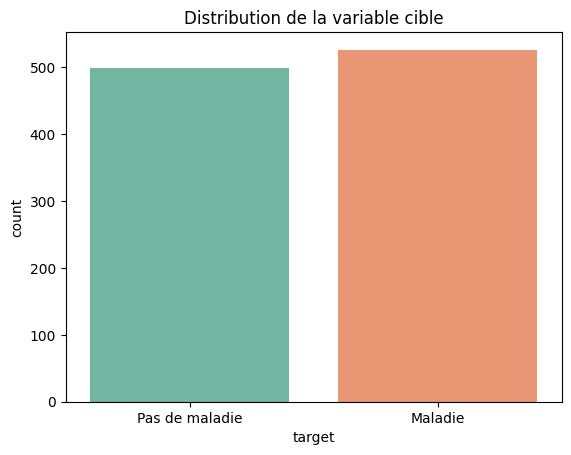

In [11]:
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Distribution de la variable cible")
plt.xticks([0, 1], ['Pas de maladie', 'Maladie'])
plt.savefig("../outputs/figures/target_distribution.png")
plt.show()

## Corrélation entre features

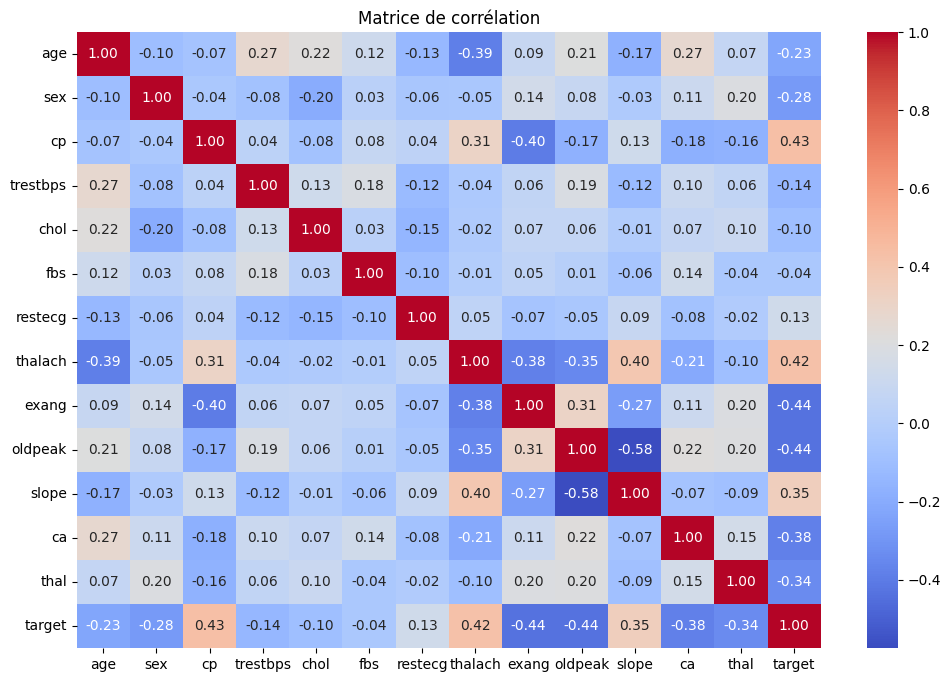

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.savefig("../outputs/figures/correlation_matrix.png")
plt.show()

## Distribution de quelques features clés

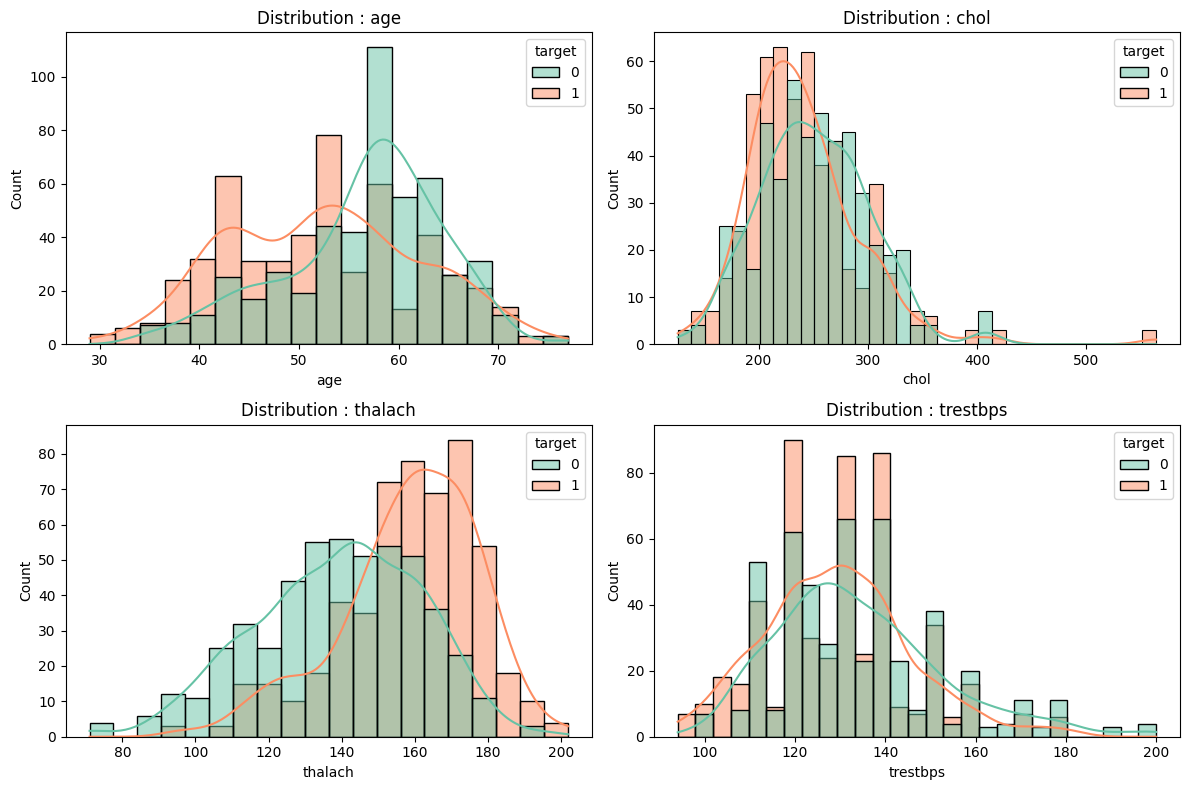

In [13]:
features_to_plot = ['age', 'chol', 'thalach', 'trestbps']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), features_to_plot):
    sns.histplot(data=df, x=feat, hue='target', kde=True, ax=ax, palette='Set2')
    ax.set_title(f"Distribution : {feat}")
plt.tight_layout()
plt.savefig("../outputs/figures/features_distribution.png")
plt.show()

## Prétraitement

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTrain : {X_train.shape}, Test : {X_test.shape}")
print("Phase 1 terminée ✅")


Train : (820, 13), Test : (205, 13)
Phase 1 terminée ✅
